In [50]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

In [51]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [52]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [53]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Support Vector Machine

### Simple model

In [54]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_sm, y_train_sm)

SVC(probability=True, random_state=42)

In [55]:
y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.74      0.76       707
           1       0.71      0.76      0.73       579

    accuracy                           0.75      1286
   macro avg       0.75      0.75      0.75      1286
weighted avg       0.75      0.75      0.75      1286



In [56]:
y_probas = svm.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.7996660709775093


## Hyperparameter Tuning

In [57]:
params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=params,
    scoring='recall',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'class_weight': [None, 'balanced'],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='recall', verbose=1)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated Recall:", grid_search.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'poly'}
Best Cross-Validated Recall: 0.8734293160915219


In [ ]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.45      0.58       707
           1       0.57      0.89      0.69       579

    accuracy                           0.65      1286
   macro avg       0.70      0.67      0.64      1286
weighted avg       0.71      0.65      0.63      1286



In [60]:
print(best_svm.score(X_train, y_train)) # Train accuracy
print(best_svm.score(X_test, y_test)) # Test accuracy

0.6568818040435459
0.645412130637636


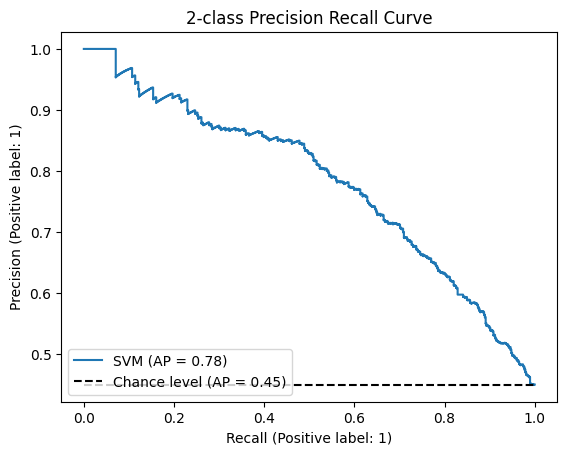

In [45]:
display = PrecisionRecallDisplay.from_estimator(
    best_svm,
    X_test,
    y_test, 
    name="SVM",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()